# Segment-Level Feature Space Visualization

This notebook builds a clean segment-level dataset for the bonus task:
- each row is one time segment
- keep only segments with high annotator agreement
- keep only segments with exactly one active class
- visualize the feature space with PCA and UMAP

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import umap
except ImportError:
    umap = None

sns.set_theme(style="whitegrid")

/Users/romacarapetean/anaconda3/envs/mlpc2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = Path.cwd().parent / "data" / "audio_features"
npz_paths = sorted(DATA_PATH.glob("*.npz"))

print(f"Found {len(npz_paths)} NPZ files")
print("First 5 files:", [p.name for p in npz_paths[:5]])

Found 3656 NPZ files
First 5 files: ['000001.npz', '000002.npz', '000003.npz', '000004.npz', '000005.npz']


## Filtering Strategy

For each recording, annotations are stored as `ann[t, c, a]` where:
- `t` = time segment
- `c` = class
- `a` = annotator

We aggregate over annotators, then keep only segments where:
- the strongest class has agreement at least `0.8`
- exactly one class is active at that threshold

Segments with no active class are skipped.

In [3]:
AGREEMENT_THRESHOLD = 0.80
OWNER_WEIGHT = 2.0

exclude_keys = {
    "start_time", "end_time", "annotations", "is_own_recording",
    "class_names", "annotator_ids", "target_classes", "non_target_classes",
    "recording_device", "recording_environments", "scene_description",
    "device_placement"
}

def flatten_segment_feature(value, prefix):
    value = np.asarray(value, dtype=float)
    if value.ndim == 0:
        return {prefix: float(value)}
    if value.ndim == 1:
        return {prefix: float(value.item()) if value.size == 1 else float(value.mean())}
    flat = value.reshape(-1)
    return {f"{prefix}_{i}": float(v) for i, v in enumerate(flat)}

def aggregate_annotations(ann, is_own_recording, owner_weight=2.0):
    weights = np.where(is_own_recording, owner_weight, 1.0).astype(float)
    return (ann * weights[None, None, :]).sum(axis=2) / weights.sum()

def build_segment_dataset(npz_paths, agreement_threshold=0.8, owner_weight=2.0):
    rows = []

    for path in npz_paths:
        with np.load(path, allow_pickle=True) as data:
            ann = data["annotations"].astype(float)       # [T, C, A]
            class_names = data["class_names"].astype(str)
            is_own = data["is_own_recording"].astype(bool)
            start_times = data["start_time"].astype(float)
            end_times = data["end_time"].astype(float)

            aggregated = aggregate_annotations(ann, is_own, owner_weight=owner_weight)  # [T, C]
            active_mask = aggregated >= agreement_threshold

            feature_keys = [
                key for key in data.files
                if key not in exclude_keys and np.issubdtype(data[key].dtype, np.number)
            ]

            for t in range(aggregated.shape[0]):
                active_classes = np.flatnonzero(active_mask[t])
                if len(active_classes) != 1:
                    continue

                class_idx = int(active_classes[0])
                row = {
                    "filename": path.stem,
                    "segment_idx": t,
                    "start_time": start_times[t],
                    "end_time": end_times[t],
                    "label": class_names[class_idx],
                    "agreement": float(aggregated[t, class_idx]),
                }

                if "recording_device" in data.files:
                    row["recording_device"] = str(np.asarray(data["recording_device"]).reshape(-1)[0])
                if "recording_environments" in data.files:
                    row["recording_environment"] = str(np.asarray(data["recording_environments"]).reshape(-1)[0])
                if "device_placement" in data.files:
                    row["device_placement"] = str(np.asarray(data["device_placement"]).reshape(-1)[0])

                for key in feature_keys:
                    value = np.asarray(data[key][t])
                    row.update(flatten_segment_feature(value, key))

                rows.append(row)

    return pd.DataFrame(rows)

segments_df = build_segment_dataset(
    npz_paths,
    agreement_threshold=AGREEMENT_THRESHOLD,
    owner_weight=OWNER_WEIGHT,
)

print("Selected segments:", len(segments_df))
print("Unique classes:", segments_df["label"].nunique())
segments_df.head()

Selected segments: 79940
Unique classes: 15


,filename,segment_idx,start_time,end_time,label,agreement,recording_device,recording_environment,device_placement,zcr_mean,...,rolloff_high_min,rolloff_high_max,energy_mean,energy_std,energy_min,energy_max,power_mean,power_std,power_min,power_max
0,000001,0,0.0,1.0,keyboard_typing,0.977064,Apple Watch A2352,office,mobile,0.108809,...,4437.50,7687.50,2.109333,0.889059,4.429392e-11,6.369324,0.121025,0.071085,9.700591e-24,0.380855
1,000001,1,0.5,1.5,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.098672,...,4437.50,7375.00,2.430274,0.768416,1.551870e+00,6.369324,0.148033,0.066443,5.499880e-02,0.420587
2,000001,2,1.0,2.0,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.088809,...,4031.25,7093.75,2.298824,0.527186,1.533484e+00,4.745509,0.142157,0.056962,4.807831e-02,0.420587
3,000001,3,1.5,2.5,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.081680,...,4031.25,6937.50,2.096365,0.282229,1.533484e+00,2.940777,0.123202,0.045264,4.807831e-02,0.253975
4,000001,4,2.0,3.0,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.083496,...,4468.75,7062.50,2.074069,0.346579,1.551129e+00,3.790800,0.114321,0.044097,4.893361e-02,0.328649


label
footsteps                     13477
running_water                 12964
keyboard_typing               11231
vacuum_cleaner                 8023
microwave                      6645
keychain                       4279
coffee_machine                 4243
phone_ringing                  4148
cutlery_dishes                 3866
toilet_flushing                3741
door_open_close                3089
wardrobe_drawer_open_close     1715
window_open_close              1229
bell_ringing                   1113
light_switch                    177


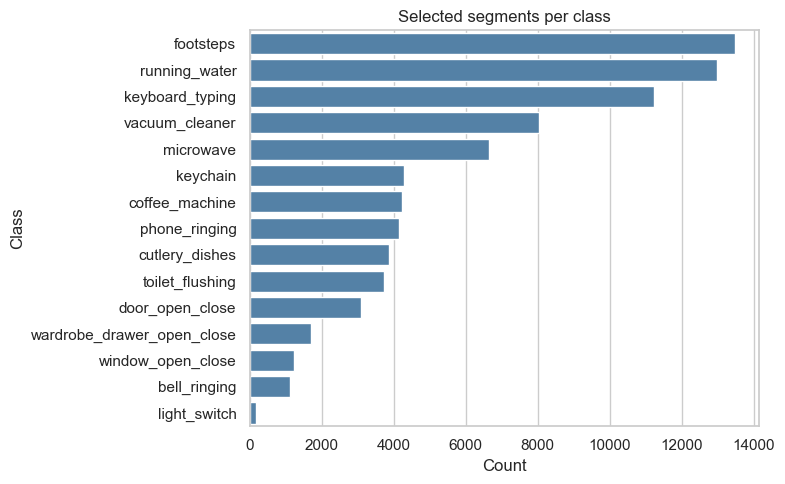

In [4]:
class_counts = segments_df["label"].value_counts().sort_values(ascending=False)
print(class_counts.to_string())

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, color="steelblue")
plt.title("Selected segments per class")
plt.xlabel("Count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

## Feature Matrix

Each row in `X` is one retained time segment. `T` is therefore not an input feature; it is only the segment index used while constructing the dataset.

In [5]:
meta_cols = {
    "filename", "segment_idx", "start_time", "end_time", "label", "agreement",
    "recording_device", "recording_environment", "device_placement"
}

feature_cols = [col for col in segments_df.columns if col not in meta_cols]

X = segments_df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)

# Drop features that are entirely missing and impute the rest with the column median.
X = X.dropna(axis=1, how="all")
X = X.fillna(X.median(numeric_only=True))

y = segments_df["label"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)
print("Number of features:", X.shape[1])
print("First 10 features:", feature_cols[:10])

X shape: (79940, 56)
Number of features: 56
First 10 features: ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std']


In [6]:
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(X_scaled)

pca_df = segments_df[["label", "agreement"]].copy()
pca_df["pc1"] = embedding_pca[:, 0]
pca_df["pc2"] = embedding_pca[:, 1]

print(f"Explained variance by PC1 and PC2: {pca.explained_variance_ratio_.sum():.3f}")
pca_df.head()

Explained variance by PC1 and PC2: 0.507


,label,agreement,pc1,pc2
0,keyboard_typing,0.977064,2.039710,2.206072
1,keyboard_typing,1.000000,0.221289,-1.226244
2,keyboard_typing,1.000000,-0.192522,-2.241112
3,keyboard_typing,1.000000,-1.004434,-3.135663
4,keyboard_typing,1.000000,-0.898598,-2.887316


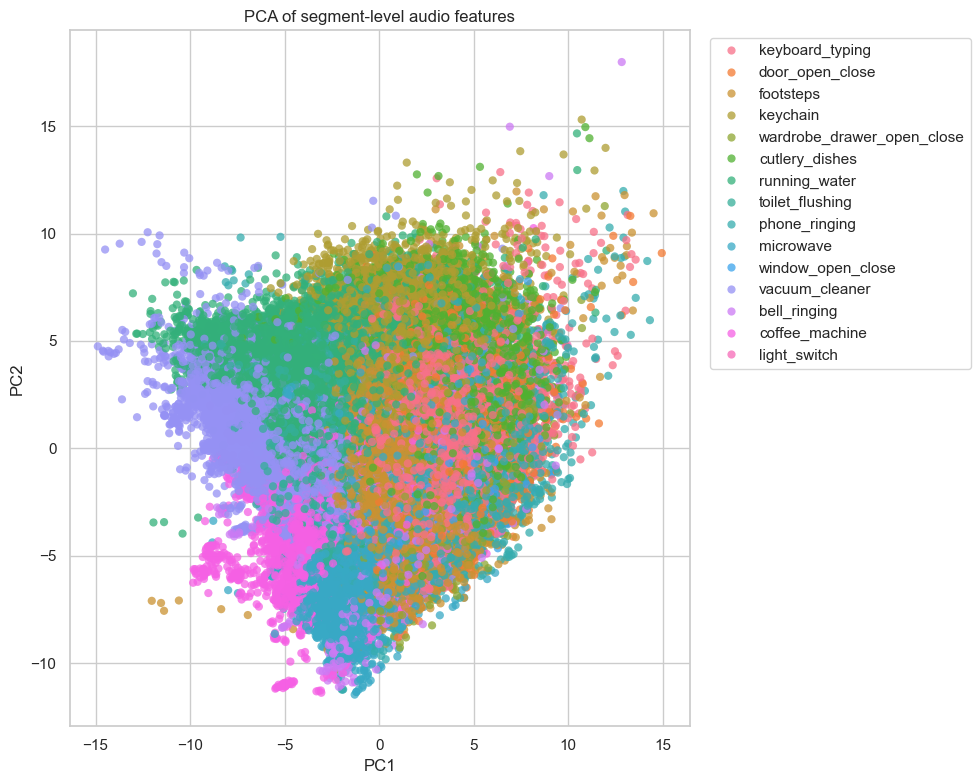

In [7]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="pc1",
    y="pc2",
    hue="label",
    alpha=0.75,
    s=35,
    linewidth=0,
)
plt.title("PCA of segment-level audio features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## UMAP

UMAP is useful here because it usually preserves local neighborhood structure better than PCA and often reveals class-level clusters more clearly.

In [13]:
if umap is None:
    print("Install umap-learn to run this section: pip install umap-learn")
else:
    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.1,
        metric="euclidean",
        random_state=42,
    )
    embedding_umap = umap_model.fit_transform(X_scaled)

    umap_df = segments_df[["label", "agreement"]].copy()
    umap_df["umap1"] = embedding_umap[:, 0]
    umap_df["umap2"] = embedding_umap[:, 1]
    umap_df.head()

/Users/romacarapetean/anaconda3/envs/mlpc2026/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


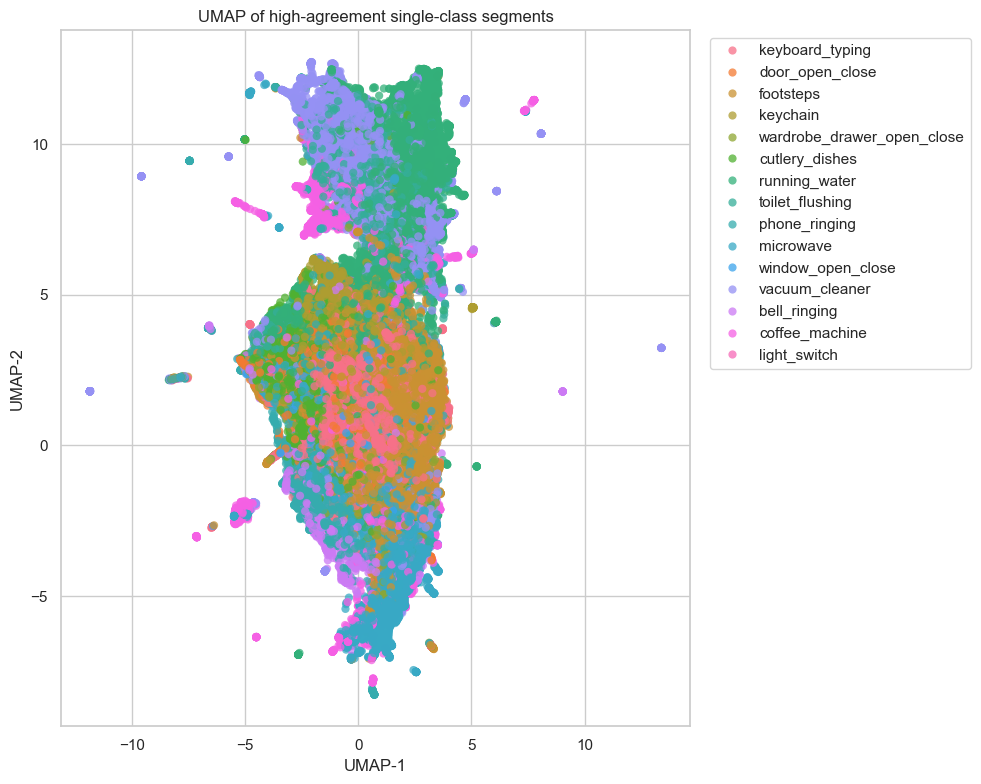

In [14]:
if umap is not None:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=umap_df,
        x="umap1",
        y="umap2",
        hue="label",
        alpha=0.75,
        s=35,
        linewidth=0,
    )
    plt.title("UMAP of high-agreement single-class segments")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [15]:
top_classes = segments_df["label"].value_counts().head(5).index.tolist()
print("Top classes to discuss in the report:", top_classes)

segments_df.groupby("label")["agreement"].agg(["count", "mean"]).sort_values("count", ascending=False).head(10)

Top classes to discuss in the report: [np.str_('footsteps'), np.str_('running_water'), np.str_('keyboard_typing'), np.str_('vacuum_cleaner'), np.str_('microwave')]


,count,mean
label,,
footsteps,13477,0.980400
running_water,12964,0.992775
keyboard_typing,11231,0.986210
vacuum_cleaner,8023,0.996728
microwave,6645,0.992989
keychain,4279,0.973182
coffee_machine,4243,0.993481
phone_ringing,4148,0.983011
cutlery_dishes,3866,0.970010


## Suggested Report Text

You can adapt the wording below after you inspect the plots:

- I used segment-level spectral and cepstral features extracted from the NPZ files. These include MFCC, mel-spectrogram, spectral centroid, bandwidth, rolloff, flatness, flux, energy, power, and zero-crossing statistics. These features were chosen because they describe timbre, spectral shape, noisiness, and temporal activity, which are relevant for distinguishing domestic sound events.
- I kept only segments with high annotation confidence by aggregating annotations over annotators and requiring at least 0.8 agreement for exactly one class. Segments with no active class or multiple active classes were removed to reduce label noise.
- I used PCA as a linear baseline and UMAP as the main non-linear down-projection method. UMAP was preferred because it preserves local neighborhoods better and typically reveals class-level clusters more clearly in audio embeddings.
- I set `n_neighbors=20` and `min_dist=0.1` for UMAP after trying values that balance local structure and cluster compactness. The final setting gave visually stable clusters without fragmenting the data into many tiny islands.
- In the final plot, some classes should form compact groups while others may overlap, indicating that certain events have more consistent acoustic patterns than others.

In [18]:
print("Full dataframe:")
display(segments_df.head())

print("\nColumns:")
print(segments_df.columns.tolist())

meta_cols = [
    "filename", "segment_idx", "start_time", "end_time",
    "label", "agreement", "recording_device",
    "recording_environment", "device_placement"
]

feature_preview = [c for c in segments_df.columns if c not in meta_cols][:15]

print("\nExample rows with a few feature columns:")
display(segments_df[["filename", "segment_idx", "label", "agreement"] + feature_preview].head())


Full dataframe:


,filename,segment_idx,start_time,end_time,label,agreement,recording_device,recording_environment,device_placement,zcr_mean,...,rolloff_high_min,rolloff_high_max,energy_mean,energy_std,energy_min,energy_max,power_mean,power_std,power_min,power_max
0,000001,0,0.0,1.0,keyboard_typing,0.977064,Apple Watch A2352,office,mobile,0.108809,...,4437.50,7687.50,2.109333,0.889059,4.429392e-11,6.369324,0.121025,0.071085,9.700591e-24,0.380855
1,000001,1,0.5,1.5,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.098672,...,4437.50,7375.00,2.430274,0.768416,1.551870e+00,6.369324,0.148033,0.066443,5.499880e-02,0.420587
2,000001,2,1.0,2.0,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.088809,...,4031.25,7093.75,2.298824,0.527186,1.533484e+00,4.745509,0.142157,0.056962,4.807831e-02,0.420587
3,000001,3,1.5,2.5,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.081680,...,4031.25,6937.50,2.096365,0.282229,1.533484e+00,2.940777,0.123202,0.045264,4.807831e-02,0.253975
4,000001,4,2.0,3.0,keyboard_typing,1.000000,Apple Watch A2352,office,mobile,0.083496,...,4468.75,7062.50,2.074069,0.346579,1.551129e+00,3.790800,0.114321,0.044097,4.893361e-02,0.328649



Columns:
['filename', 'segment_idx', 'start_time', 'end_time', 'label', 'agreement', 'recording_device', 'recording_environment', 'device_placement', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'pow

,filename,segment_idx,label,agreement,zcr_mean,zcr_std,zcr_min,zcr_max,melspect_mean,melspect_std,melspect_min,melspect_max,mfcc_mean,mfcc_std,mfcc_min,mfcc_max,mfcc_d_mean,mfcc_d_std,mfcc_d_min
0,000001,0,keyboard_typing,0.977064,0.108809,0.074025,0.000000,0.437500,2.949282,0.859564,7.086020e-10,4.477617,-2.440088,0.974943,-5.501147,-0.414891,0.021236,0.156626,-0.307752
1,000001,1,keyboard_typing,1.000000,0.098672,0.065039,0.035156,0.437500,3.173200,0.531762,1.790399e+00,4.555051,-2.338845,0.781121,-4.352996,-0.423490,0.000133,0.125244,-0.309301
2,000001,2,keyboard_typing,1.000000,0.088809,0.044263,0.029297,0.261719,3.133178,0.503693,1.763294e+00,4.414987,-2.312366,0.744691,-4.199794,-0.464090,0.000724,0.119782,-0.294076
3,000001,3,keyboard_typing,1.000000,0.081680,0.034051,0.029297,0.226562,3.075114,0.456152,1.744914e+00,4.146260,-2.339354,0.681645,-4.045150,-0.651439,-0.001724,0.110749,-0.264795
4,000001,4,keyboard_typing,1.000000,0.083496,0.037198,0.029297,0.234375,3.078775,0.468707,1.815783e+00,4.247745,-2.382504,0.697333,-4.150286,-0.682883,-0.001114,0.114753,-0.286478


In [20]:
print("X shape:", X.shape)
display(X.head())
print("y:")
display(y.head())


X shape: (79940, 56)


,zcr_mean,zcr_std,zcr_min,zcr_max,melspect_mean,melspect_std,melspect_min,melspect_max,mfcc_mean,mfcc_std,...,rolloff_high_min,rolloff_high_max,energy_mean,energy_std,energy_min,energy_max,power_mean,power_std,power_min,power_max
0,0.108809,0.074025,0.000000,0.437500,2.949282,0.859564,7.086020e-10,4.477617,-2.440088,0.974943,...,4437.50,7687.50,2.109333,0.889059,4.429392e-11,6.369324,0.121025,0.071085,9.700591e-24,0.380855
1,0.098672,0.065039,0.035156,0.437500,3.173200,0.531762,1.790399e+00,4.555051,-2.338845,0.781121,...,4437.50,7375.00,2.430274,0.768416,1.551870e+00,6.369324,0.148033,0.066443,5.499880e-02,0.420587
2,0.088809,0.044263,0.029297,0.261719,3.133178,0.503693,1.763294e+00,4.414987,-2.312366,0.744691,...,4031.25,7093.75,2.298824,0.527186,1.533484e+00,4.745509,0.142157,0.056962,4.807831e-02,0.420587
3,0.081680,0.034051,0.029297,0.226562,3.075114,0.456152,1.744914e+00,4.146260,-2.339354,0.681645,...,4031.25,6937.50,2.096365,0.282229,1.533484e+00,2.940777,0.123202,0.045264,4.807831e-02,0.253975
4,0.083496,0.037198,0.029297,0.234375,3.078775,0.468707,1.815783e+00,4.247745,-2.382504,0.697333,...,4468.75,7062.50,2.074069,0.346579,1.551129e+00,3.790800,0.114321,0.044097,4.893361e-02,0.328649


y:


0    keyboard_typing
1    keyboard_typing
2    keyboard_typing
3    keyboard_typing
4    keyboard_typing
Name: label, dtype: str